# Working with synthetic data

In [1]:
###### defining the ideal transmission amplitude as function of frequency w #######
# from equation (A1) in https://arxiv.org/pdf/2307.07765

from numpy import cos, exp, abs

def s_out_in(
    A, # amplitude
    k, # tilt in the spectrum
    w_0, # center of the spectrum
    phi, # phase rotation induced by capacitive coupling to other lines
    k_p, # external coupling rate of the Purcell filter
    w_p, # Purcell filter frequency
    w_res_0, # resonator frequency at state 0
    w_res_1, # frequency at state 1
    J, # the transmon resonator coupling rate
    ):

    return lambda w: (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0)))), lambda w: (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_1)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_1))))

### using data with no noise, no tilt, no center dislocation, and no phase rotation induced by couplings

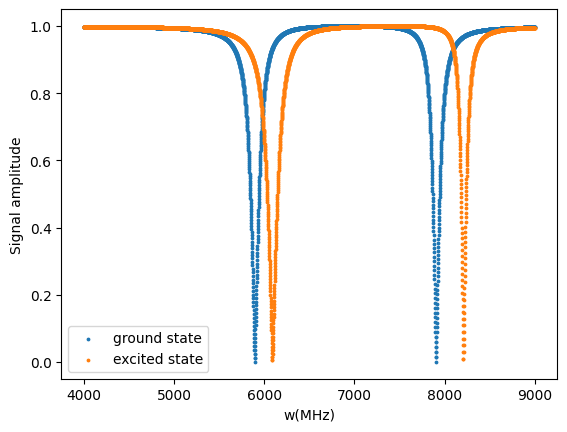

In [2]:
import matplotlib.pyplot as plt
import numpy as np

test_0,test_1 = s_out_in(A=1, k=0,w_0=0, phi=0,k_p=3e2,w_p=6.8e3,w_res_0=7e3,w_res_1=7.5e3,J=1000)

x = (1e3)*np.linspace(4,9,5001)
data_0 = test_0(x)
data_1 = test_1(x)
plt.scatter(x,data_0, s=3, label="ground state")
plt.scatter(x,data_1, s=3, label="excited state")
plt.xlabel("w(MHz)")
plt.ylabel("Signal amplitude")
plt.legend()

In [56]:
# fitting a curve to the data
from scipy.optimize import curve_fit

# the fitting curve
def s_out_in_for_fitting_0(w,A,k,w_0,phi,k_p,w_p,w_res_0,J):
    return (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0))))

# Initial guesses for parameters
initial_guess = [1.1,0,0,0,3.1e2,6.8e3,7e3,1005]

popt, pcov = curve_fit(s_out_in_for_fitting_0, x, data_0, p0=initial_guess)

/tmp/ipykernel_756969/2024393335.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(s_out_in_for_fitting_0, x, data_0, p0=initial_guess)


In [119]:
y_values = [s_out_in_for_fitting_0(w,popt[0],popt[1],popt[2],popt[3],popt[4],popt[5],popt[6],popt[7]) for w in x]

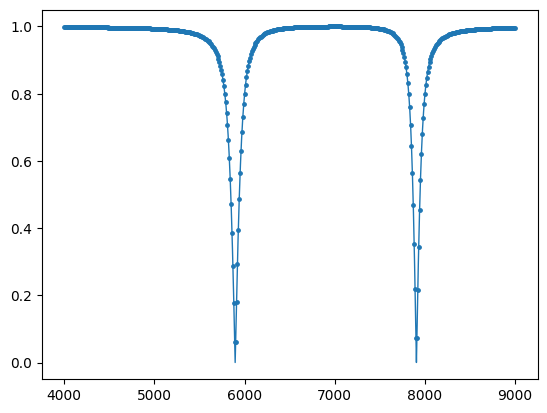

In [129]:
plt.scatter(x[::10],data_0[::10],s=6)
plt.plot(x,y_values, lw=1)

In [131]:
# using least square
from scipy.optimize import least_squares

def residuals(params, w, y):
    A,k,w_0,phi,k_p,w_p,w_res_0,J = params
    return (A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0)))) - y

result = least_squares(residuals, x0=[1.1,0,0,0,3.1e2,6.8e3,7e3,1005], args=(x, data_0))


### using data with error bars

In [33]:
# using least square
from scipy.optimize import least_squares

def residuals(params, w, y, y_err):
    A,k,w_0,phi,k_p,w_p,w_res_0,J = params
    return ((A + k*(w-w_0))*abs(cos(phi)-exp(1j*phi)*(k_p*(-2j*(w-w_res_0)))/(4*J**2+(k_p-2j*(w-w_p))*(-2j*(w-w_res_0)))) - y)/y_err

y_err = [0.0005]*len(data_0)

result = least_squares(residuals, x0=[1.1,0,0,0,3.1e2,6.8e3,7e3,1005], args=(x, data_0, y_err))

In [34]:
dof = len(data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(7.570207566994054e-11)

### using data with error bars and noise

In [61]:
from numpy.random import random

noise = (random(len(data_0))-0.5)/2
noise[:20]

array([ 0.23167111, -0.21595481,  0.03882111,  0.18779801, -0.15732883,
        0.24669117,  0.17326224,  0.14317281,  0.17326887, -0.19953833,
       -0.01798479,  0.12431084, -0.09664666, -0.02614215, -0.24296669,
        0.03892191,  0.23334373,  0.16516082,  0.20008347, -0.0571257 ])

In [ ]:
noise_data_0 = data_0 + noise
data_error_bars = [0.1]*len(data_0)

result = least_squares(residuals, x0=[1.1,0,0,0,3.1e2,6.8e3,7e3,1005], args=(x, noise_data_0, data_error_bars))

In [79]:
dof = len(noise_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(4.256791876444793)

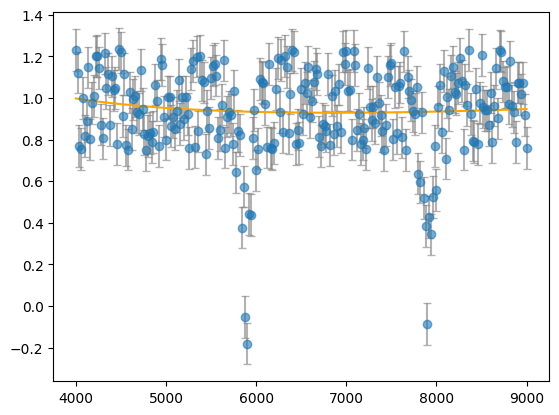

In [93]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(x,*result.x)

plt.errorbar(x[::20],noise_data_0[::20],yerr=data_error_bars[::20], fmt="o", capsize=3, ecolor="gray", alpha=0.6)
plt.plot(x,y_fit, color="orange")

### finding baseline (a.k.a A) guess from data

In [ ]:
baseline_guess = np.average(noise_data_0) # averaging y points to guess the base amplitude
k_guess = 0 # for ideal cases it should be zero
w_0_guess = 0 # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

In [98]:
result = least_squares(residuals, x0=initial_guess, args=(x, noise_data_0, data_error_bars))
dof = len(noise_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(2.064993747565254)

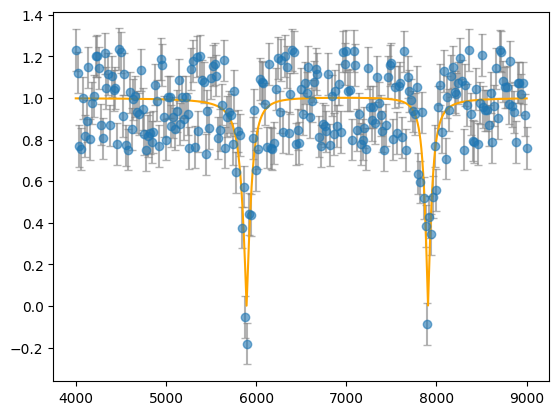

In [99]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(x,*result.x)

plt.errorbar(x[::20],noise_data_0[::20],yerr=data_error_bars[::20], fmt="o", capsize=3, ecolor="gray", alpha=0.6)
plt.plot(x,y_fit, color="orange")

### guessing baseline A, initial tilt k and center dislocation w_0 from linear fit

In [102]:
from scipy.optimize import curve_fit
import numpy as np

def linear_model(x, m, b, c):
    return m * (x + b) + c

params, covariance = curve_fit(linear_model, x, noise_data_0, sigma= data_error_bars,absolute_sigma=True)

m, b, c = params
m_err, b_err, c_err = np.sqrt(np.diag(covariance))

print("m:", m, "+/-", m_err)
print("b:", b, "+/-", b_err)
print("c:", c, "+/-", c_err)

m: -7.3069740681097535e-06 +/- 9.795021137321294e-07
b: -6476.509686351204 +/- 5880657788.148863
c: 0.9428129692625465 +/- 42962.40604178369


In [103]:
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

In [104]:
#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(x, noise_data_0, data_error_bars))
dof = len(noise_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(2.0649937474654556)

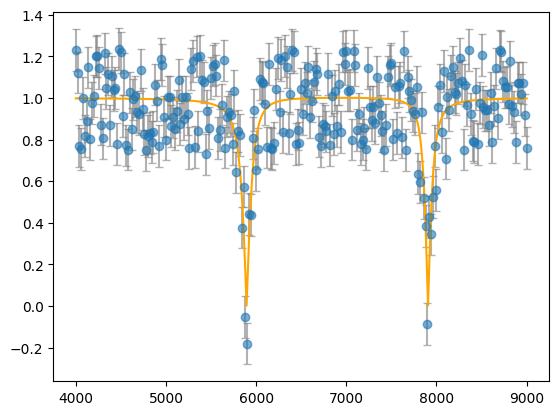

In [105]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(x,*result.x)

plt.errorbar(x[::20],noise_data_0[::20],yerr=data_error_bars[::20], fmt="o", capsize=3, ecolor="gray", alpha=0.6)
plt.plot(x,y_fit, color="orange")

### testing it with tilted data and dislocated centers

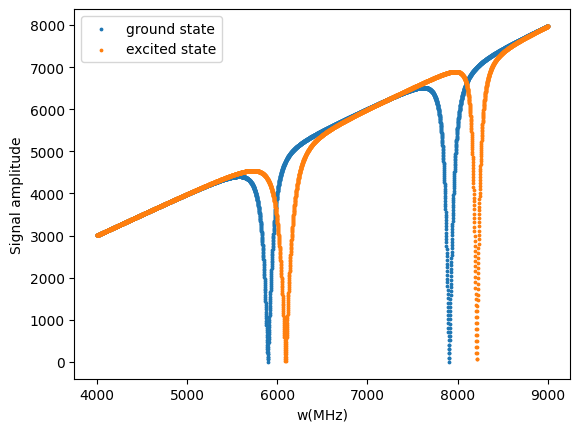

In [176]:
# generating the data
import matplotlib.pyplot as plt
import numpy as np

tilted_test_0,tilted_test_1 = s_out_in(A=10, k=1,w_0=1000, phi=0,k_p=3e2,w_p=6.8e3,w_res_0=7e3,w_res_1=7.5e3,J=1000)

tilted_x = (1e3)*np.linspace(4,9,5001)
tilted_data_0 = tilted_test_0(x)
tilted_data_1 = tilted_test_1(x)
plt.scatter(tilted_x,tilted_data_0, s=3, label="ground state")
plt.scatter(tilted_x,tilted_data_1, s=3, label="excited state")
plt.xlabel("w(MHz)")
plt.ylabel("Signal amplitude")
plt.legend()

In [177]:
# adding noise
noise_tilted_data_0 = tilted_data_0 + noise
tilted_data_error_bars = [500]*len(tilted_data_0)

In [178]:
# guessing A,k,w_0
from scipy.optimize import curve_fit
import numpy as np

def linear_model(x, m, b, c):
    return m * (x + b) + c

params, covariance = curve_fit(linear_model, tilted_x, noise_tilted_data_0, sigma=tilted_data_error_bars,absolute_sigma=True)

m, b, c = params
m_err, b_err, c_err = np.sqrt(np.diag(covariance))

print("m:", m, "+/-", m_err)
print("b:", b, "+/-", b_err)
print("c:", c, "+/-", c_err)

m: 0.9222272394029073 +/- 0.004899460186042982
b: -6301.9372058767985 +/- 1138035606.7773466
c: 4991.760466051088 +/- 1049527435.1803491


In [179]:
# adjusting guesses and fitting
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(tilted_x, noise_tilted_data_0, tilted_data_error_bars))
dof = len(noise_tilted_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(8.260237058525045e-08)

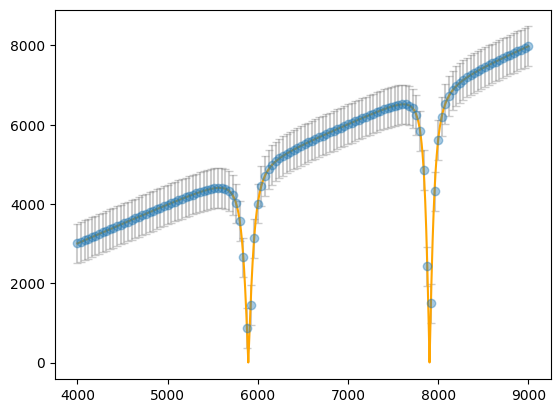

In [180]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(tilted_x,*result.x)

plt.errorbar(tilted_x[::40],noise_tilted_data_0[::40],yerr=tilted_data_error_bars[::40], fmt="o", capsize=3, ecolor="gray", alpha=0.4)
plt.plot(tilted_x,y_fit, color="orange")

### using typical guesses for not provided specsheet parameters

In [229]:
# adjusting guesses and fitting
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.9e3 # also from specsheet
w_res_0_guess = 7.1e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(tilted_x, noise_tilted_data_0, tilted_data_error_bars))
dof = len(noise_tilted_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(8.260237058524213e-08)

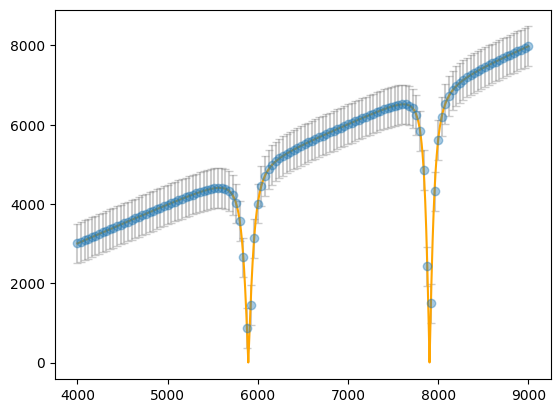

In [230]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(tilted_x,*result.x)

plt.errorbar(tilted_x[::40],noise_tilted_data_0[::40],yerr=tilted_data_error_bars[::40], fmt="o", capsize=3, ecolor="gray", alpha=0.4)
plt.plot(tilted_x,y_fit, color="orange")

### testing in data with nonvanishing phi

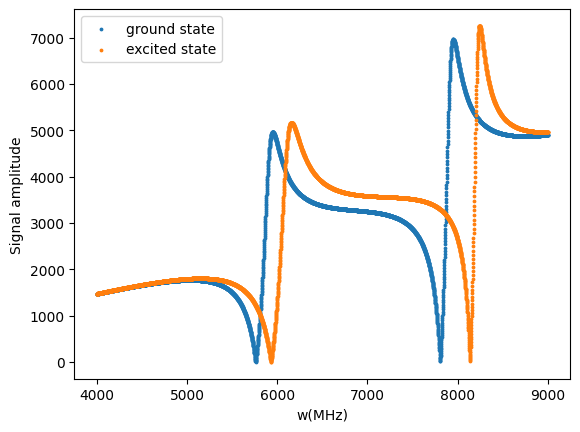

In [231]:
# generating the data
import matplotlib.pyplot as plt
import numpy as np

nvphi_test_0,nvphi_test_1 = s_out_in(A=10, k=1,w_0=1000, phi=1,k_p=3e2,w_p=6.8e3,w_res_0=7e3,w_res_1=7.5e3,J=1000)

nvphi_x = (1e3)*np.linspace(4,9,5001)
nvphi_data_0 = nvphi_test_0(x)
nvphi_data_1 = nvphi_test_1(x)
plt.scatter(nvphi_x,nvphi_data_0, s=3, label="ground state")
plt.scatter(nvphi_x,nvphi_data_1, s=3, label="excited state")
plt.xlabel("w(MHz)")
plt.ylabel("Signal amplitude")
plt.legend()

In [232]:
# adding noise
noise_nvphi_data_0 = nvphi_data_0 + noise
nvphi_data_error_bars = [500]*len(nvphi_data_0)

In [233]:
# guessing A,k,w_0
from scipy.optimize import curve_fit
import numpy as np

def linear_model(x, m, b, c):
    return m * (x + b) + c

params, covariance = curve_fit(linear_model, nvphi_x, noise_nvphi_data_0, sigma=nvphi_data_error_bars,absolute_sigma=True)

m, b, c = params
m_err, b_err, c_err = np.sqrt(np.diag(covariance))

print("m:", m, "+/-", m_err)
print("b:", b, "+/-", b_err)
print("c:", c, "+/-", c_err)

m: 0.7899819291647698 +/- 0.004899827450395988
b: 41819.13105135312 +/- 1518749939.2720702
c: -35125.74007041982 +/- 1199784963.9089093


In [234]:
# adjusting guesses and fitting
baseline_guess = c
k_guess = m # for ideal cases it should be zero
w_0_guess = -b # for ideal cases it should be zero
phi_guess = 0 # for ideal cases it should be zero
k_p_guess = 3.1e2 # should be given from specsheet
w_p_guess = 6.8e3 # also from specsheet
w_res_0_guess = 7e3 # from specsheet too
J_guess = 1005 # also from specsheet
initial_guess = [baseline_guess,k_guess,w_0_guess,phi_guess,k_p_guess,w_p_guess,w_res_0_guess, J_guess]

#fitting previous data from these guesses
result = least_squares(residuals, x0=initial_guess, args=(nvphi_x, noise_nvphi_data_0, nvphi_data_error_bars))
dof = len(noise_nvphi_data_0)-len(result.x)
chi2 = sum(result.fun**2)
red_chi2 = chi2/dof
red_chi2

np.float64(8.260531411615492e-08)

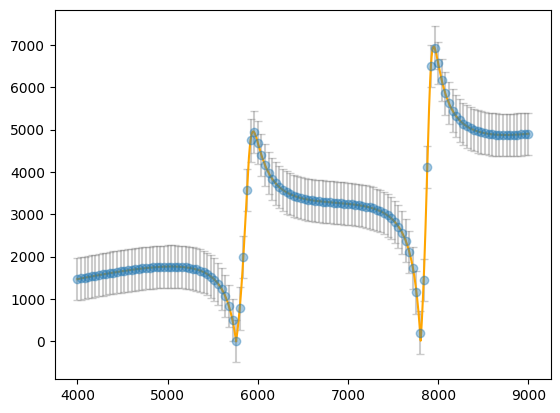

In [235]:
import matplotlib.pyplot as plt

y_fit = s_out_in_for_fitting_0(nvphi_x,*result.x)

plt.errorbar(nvphi_x[::40],noise_nvphi_data_0[::40],yerr=nvphi_data_error_bars[::40], fmt="o", capsize=3, ecolor="gray", alpha=0.4)
plt.plot(nvphi_x,y_fit, color="orange")